# 04B — Party-aware TF-IDF validation

本 Notebook 检验同一份议案文本是否应由不同政党模型分别解释。

核心设计：

1. 仅使用 Train 的唯一议案文本建立一套共享 TF-IDF 词表；
2. 四个政党共享相同的文本向量；
3. 每个政党只使用自己的历史 `support/oppose` 标签训练一个 Logistic Regression 分类头；
4. 比较纯文本、word+char、以及 word+char+结构化特征；
5. 只在 Validation 进行模型比较和阈值诊断，默认不读取 Test 结果。

这样，同一议案可以得到四个不同的政党支持概率。

In [1]:
# 导入本 Notebook 需要的库。
from pathlib import Path
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
TARGET = 'target_binary_support'
TEXT_COLUMN = 'model_text'

# 第一次运行时保持 False，避免提前查看 Test。
RUN_FINAL_TEST = False

# 这些标准用于判断模型是否足以暂缓 P2，而不是模型自动学习的参数。
MIN_VALIDATION_MACRO_F1 = 0.72
MIN_IMPROVEMENT_OVER_PARTY_BASELINE = 0.05
MIN_WORST_PARTY_MACRO_F1 = 0.60

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'processed' / 'model_v2'
OUTPUT_DIR = DATA_DIR / 'baseline_party_aware'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'model_train_v2.csv'
VALIDATION_PATH = DATA_DIR / 'model_validation_v2.csv'
TEST_PATH = DATA_DIR / 'model_test_v2.csv'

print('Data directory:', DATA_DIR)
print('RUN_FINAL_TEST:', RUN_FINAL_TEST)

Data directory: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/model_v2
RUN_FINAL_TEST: False


## 1. Load data and verify split safety

这里会读取三个文件以检查字段和议案是否重叠，但在 `RUN_FINAL_TEST=False` 时不会训练、预测或显示 Test 指标。

In [2]:
# 读取模型数据，并重建连续索引，方便稀疏矩阵按行切片。
train = pd.read_csv(TRAIN_PATH).reset_index(drop=True)
validation = pd.read_csv(VALIDATION_PATH).reset_index(drop=True)
test = pd.read_csv(TEST_PATH).reset_index(drop=True)

for frame in (train, validation, test):
    frame[TARGET] = frame[TARGET].astype(int)
    frame[TEXT_COLUMN] = frame[TEXT_COLUMN].fillna('').astype(str)

# 检查同一议案不会跨数据集出现，避免文本泄漏。
assert train['row_id'].is_unique
assert validation['row_id'].is_unique
assert test['row_id'].is_unique
assert not set(train['division_key']) & set(validation['division_key'])
assert not set(train['division_key']) & set(test['division_key'])
assert not set(validation['division_key']) & set(test['division_key'])

overview = pd.DataFrame({
    'rows': [len(train), len(validation), len(test)],
    'divisions': [
        train['division_key'].nunique(),
        validation['division_key'].nunique(),
        test['division_key'].nunique(),
    ],
    'parties': [
        train['party'].nunique(),
        validation['party'].nunique(),
        test['party'].nunique(),
    ],
    'support_rate': [
        train[TARGET].mean(),
        validation[TARGET].mean(),
        np.nan,
    ],
}, index=['train', 'validation', 'test'])

display(overview.round(3))

# 每个政党必须在 Train 和 Validation 中同时拥有两个标签。
party_label_audit = (
    pd.concat([
        train.assign(split='train'),
        validation.assign(split='validation'),
    ], ignore_index=True)
    .groupby(['split', 'party'])[TARGET]
    .agg(rows='size', support_rate='mean', label_count='nunique')
    .reset_index()
)
assert party_label_audit['label_count'].eq(2).all(), '某个政党在某个数据集中只有一种标签。'
display(party_label_audit.round(3))

,rows,divisions,parties,support_rate
train,2822,770,4,0.569
validation,570,169,4,0.591
test,1289,354,4,NaN


,split,party,rows,support_rate,label_count
0,train,conservative,769,0.494,2
1,train,green,663,0.585,2
2,train,labour,700,0.596,2
3,train,liberal-democrat,690,0.610,2
4,validation,conservative,159,0.358,2
5,validation,green,135,0.696,2
6,validation,labour,151,0.629,2
7,validation,liberal-democrat,125,0.728,2


## 2. Define leakage-safe features

所有特征必须能在投票前获得。投票票数、最终多数和由当前投票计算出的目标字段都禁止作为输入。

In [3]:
# 每个政党模型都共享这些结构化字段；party 本身不需要输入，因为模型身份已经代表政党。
CATEGORICAL_COLUMNS = [
    'party_role',
    'party_object_alignment',
    'motion_type',
    'motion_family',
    'policy_domain_primary',
    'policy_domain_confidence',
    'government_party',
    'main_opposition_party',
]

NUMERIC_COLUMNS = [
    'motion_year',
    'motion_month',
    'years_since_2016',
    'motion_char_count',
    'motion_word_count',
    'model_text_char_count',
    'model_text_word_count',
    'total_possible_members',
    'has_legislation_name',
    'bill_link_available',
    'is_governing_party',
    'is_main_opposition',
    'is_opposition_day',
    'is_amendment',
    'is_new_clause',
    'is_financial_motion',
    'government_backing_known',
    'final_object_government_backed',
    'legacy_domain_count',
    'policy_domain_count',
    'is_econ_finance',
    'is_justice_security',
    'is_env_infra',
    'is_social_health',
    'is_national_affairs',
]

FORBIDDEN_FEATURES = {
    'party_result', 'raw_vote_score', 'party_for', 'party_against',
    'party_for_percentage', 'party_majority', 'party_absent',
    'total_for', 'total_against', 'total_result', 'total_majority',
    'target_policy_result', 'target_policy_stance_score',
    'target_policy_stance', 'target_ordinal_provisional', TARGET,
}

selected_features = {TEXT_COLUMN, *CATEGORICAL_COLUMNS, *NUMERIC_COLUMNS}
assert not selected_features & FORBIDDEN_FEATURES
missing_columns = selected_features - set(train.columns)
assert not missing_columns, f'Missing features: {sorted(missing_columns)}'

print('Text columns: 1')
print('Categorical columns:', len(CATEGORICAL_COLUMNS))
print('Numeric columns:', len(NUMERIC_COLUMNS))

Text columns: 1
Categorical columns: 8
Numeric columns: 25


## 3. Build one shared TF-IDF representation

TF-IDF 只在 Train 的唯一议案上拟合。相同议案不会因为出现四个政党而在 IDF 中被重复计算。Validation 和 Test 只进行转换。

In [4]:
def make_word_vectorizer():
    # 提取单词和连续双词，并过滤极少或极常见的词。
    return TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        max_features=30000,
        sublinear_tf=True,
    )


def make_char_vectorizer():
    # 字符片段帮助模型识别词形变化和拼写差异。
    return TfidfVectorizer(
        analyzer='char_wb',
        lowercase=True,
        ngram_range=(3, 5),
        min_df=3,
        max_features=30000,
        sublinear_tf=True,
    )


def make_structured_transformer():
    # 类别字段进行 one-hot，数值字段用中位数补缺并缩放。
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore')),
    ])
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        ('categorical', categorical_pipeline, CATEGORICAL_COLUMNS),
        ('numeric', numeric_pipeline, NUMERIC_COLUMNS),
    ], remainder='drop')


def fit_shared_features(train_frame, evaluation_frame):
    # 词表只根据 Train 中每个 division 的一份文本建立。
    unique_train_text = (
        train_frame.drop_duplicates('division_key')[TEXT_COLUMN]
        .fillna('')
        .astype(str)
    )

    word_vectorizer = make_word_vectorizer()
    char_vectorizer = make_char_vectorizer()
    structured_transformer = make_structured_transformer()

    word_vectorizer.fit(unique_train_text)
    char_vectorizer.fit(unique_train_text)
    structured_transformer.fit(train_frame)

    train_word = word_vectorizer.transform(train_frame[TEXT_COLUMN])
    eval_word = word_vectorizer.transform(evaluation_frame[TEXT_COLUMN])
    train_char = char_vectorizer.transform(train_frame[TEXT_COLUMN])
    eval_char = char_vectorizer.transform(evaluation_frame[TEXT_COLUMN])
    train_structured = structured_transformer.transform(train_frame)
    eval_structured = structured_transformer.transform(evaluation_frame)

    train_matrices = {
        'party_heads_word': train_word,
        'party_heads_word_char': hstack([train_word, train_char], format='csr'),
        'party_heads_full': hstack(
            [train_word, train_char, train_structured], format='csr'
        ),
    }
    eval_matrices = {
        'party_heads_word': eval_word,
        'party_heads_word_char': hstack([eval_word, eval_char], format='csr'),
        'party_heads_full': hstack(
            [eval_word, eval_char, eval_structured], format='csr'
        ),
    }

    fitted_transformers = {
        'word': word_vectorizer,
        'char': char_vectorizer,
        'structured': structured_transformer,
    }
    return train_matrices, eval_matrices, fitted_transformers


started = time.perf_counter()
train_matrices, validation_matrices, fitted_transformers = fit_shared_features(
    train, validation
)
feature_seconds = time.perf_counter() - started

feature_overview = pd.DataFrame({
    'train_shape': [str(matrix.shape) for matrix in train_matrices.values()],
    'validation_shape': [
        str(validation_matrices[name].shape) for name in train_matrices
    ],
}, index=train_matrices.keys())

print(f'Shared feature construction: {feature_seconds:.2f}s')
display(feature_overview)

Shared feature construction: 1.64s


,train_shape,validation_shape
party_heads_word,"(2822, 7716)","(570, 7716)"
party_heads_word_char,"(2822, 23514)","(570, 23514)"
party_heads_full,"(2822, 23583)","(570, 23583)"


## 4. Evaluation helpers and simple baselines

`party_prior` 不阅读文本，只把 Train 中每个政党的历史支持率用于 Validation，是 party-aware 模型必须超过的业务基线。

In [5]:
def safe_roc_auc(y_true, probabilities):
    # 只有一个真实类别时 ROC-AUC 无定义。
    return (
        roc_auc_score(y_true, probabilities)
        if pd.Series(y_true).nunique() == 2
        else np.nan
    )


def evaluate_probabilities(y_true, probabilities, threshold=0.5):
    # 使用给定阈值把支持概率转换为二分类结果。
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, predictions),
        'balanced_accuracy': balanced_accuracy_score(y_true, predictions),
        'macro_f1': f1_score(
            y_true, predictions, average='macro', zero_division=0
        ),
        'support_precision': precision_score(
            y_true, predictions, zero_division=0
        ),
        'support_recall': recall_score(y_true, predictions, zero_division=0),
        'support_f1': f1_score(y_true, predictions, zero_division=0),
        'roc_auc': safe_roc_auc(y_true, probabilities),
        'log_loss': log_loss(y_true, probabilities, labels=[0, 1]),
        'brier': brier_score_loss(y_true, probabilities),
        'threshold': threshold,
    }


def find_best_threshold(y_true, probabilities):
    # 在 Validation 的 0.25–0.75 之间寻找 Macro-F1 最高的阈值。
    candidates = np.round(np.arange(0.25, 0.751, 0.01), 2)
    scores = np.array([
        f1_score(
            y_true,
            (np.asarray(probabilities) >= threshold).astype(int),
            average='macro',
            zero_division=0,
        )
        for threshold in candidates
    ])
    best_index = int(np.argmax(scores))
    curve = pd.DataFrame({'threshold': candidates, 'macro_f1': scores})
    return float(candidates[best_index]), float(scores[best_index]), curve


def subgroup_metrics(frame, probabilities, group_column, threshold):
    # 分组检查模型，避免整体平均值掩盖某个政党的失败。
    work = frame[[group_column, TARGET]].copy()
    work['probability'] = np.asarray(probabilities)
    work['prediction'] = work['probability'].ge(threshold).astype(int)
    rows = []
    for group, subset in work.groupby(group_column, dropna=False):
        rows.append({
            group_column: group,
            'rows': len(subset),
            'support_rate': subset[TARGET].mean(),
            'predicted_support_rate': subset['prediction'].mean(),
            'mean_probability': subset['probability'].mean(),
            'accuracy': accuracy_score(subset[TARGET], subset['prediction']),
            'balanced_accuracy': (
                balanced_accuracy_score(subset[TARGET], subset['prediction'])
                if subset[TARGET].nunique() == 2 else np.nan
            ),
            'macro_f1': (
                f1_score(
                    subset[TARGET], subset['prediction'],
                    average='macro', zero_division=0,
                )
                if subset[TARGET].nunique() == 2 else np.nan
            ),
        })
    return pd.DataFrame(rows).sort_values('macro_f1', na_position='last')


y_train = train[TARGET].to_numpy()
y_validation = validation[TARGET].to_numpy()
validation_rows = []
validation_probabilities = {}

# 全局先验为所有记录分配同一个 Train 支持率。
global_prior = float(train[TARGET].mean())
global_probabilities = np.full(len(validation), global_prior)
global_metrics = evaluate_probabilities(y_validation, global_probabilities)
global_metrics.update({'model': 'global_prior', 'fit_seconds': 0.0})
validation_rows.append(global_metrics)
validation_probabilities['global_prior'] = global_probabilities

# 政党先验为每条记录分配对应政党在 Train 中的历史支持率。
party_prior_table = train.groupby('party')[TARGET].mean()
party_prior_probabilities = (
    validation['party'].map(party_prior_table).fillna(global_prior).to_numpy()
)
party_prior_metrics = evaluate_probabilities(
    y_validation, party_prior_probabilities
)
party_prior_metrics.update({'model': 'party_prior', 'fit_seconds': 0.0})
validation_rows.append(party_prior_metrics)
validation_probabilities['party_prior'] = party_prior_probabilities

display(party_prior_table.rename('train_support_rate').to_frame().round(3))

,train_support_rate
party,
conservative,0.494
green,0.585
labour,0.596
liberal-democrat,0.610


## 5. Train one Logistic Regression head per party

每个分类头只使用对应政党的 Train 行。TF-IDF 和结构化编码方式保持共享，因此四个模型面对的是同一种特征空间。

In [6]:
def make_classifier():
    # balanced 权重降低类别比例差异对训练的影响。
    return LogisticRegression(
        solver='liblinear',
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
    )


def fit_party_heads(train_frame, evaluation_frame, train_matrix, eval_matrix):
    # 输出顺序与 evaluation_frame 保持一致，便于计算整体和分政党指标。
    probabilities = np.full(len(evaluation_frame), np.nan, dtype=float)
    models = {}
    training_rows = []

    for party in sorted(train_frame['party'].unique()):
        train_mask = train_frame['party'].eq(party).to_numpy()
        eval_mask = evaluation_frame['party'].eq(party).to_numpy()

        y_party = train_frame.loc[train_mask, TARGET].astype(int).to_numpy()
        assert set(np.unique(y_party)) == {0, 1}, f'{party} Train 缺少一个类别。'

        classifier = make_classifier()
        classifier.fit(train_matrix[train_mask], y_party)
        positive_index = list(classifier.classes_).index(1)
        probabilities[eval_mask] = classifier.predict_proba(
            eval_matrix[eval_mask]
        )[:, positive_index]
        models[party] = classifier
        training_rows.append({
            'party': party,
            'train_rows': int(train_mask.sum()),
            'validation_rows': int(eval_mask.sum()),
            'train_support_rate': float(y_party.mean()),
        })

    assert not np.isnan(probabilities).any(), '存在未获得政党模型预测的行。'
    return probabilities, models, pd.DataFrame(training_rows)


fitted_party_heads = {}
training_audits = {}

for model_name in train_matrices:
    started = time.perf_counter()
    probabilities, models, training_audit = fit_party_heads(
        train,
        validation,
        train_matrices[model_name],
        validation_matrices[model_name],
    )
    fit_seconds = time.perf_counter() - started

    metrics = evaluate_probabilities(y_validation, probabilities, threshold=0.5)
    metrics.update({'model': model_name, 'fit_seconds': fit_seconds})
    validation_rows.append(metrics)
    validation_probabilities[model_name] = probabilities
    fitted_party_heads[model_name] = models
    training_audits[model_name] = training_audit

    print(
        f'{model_name}: macro_f1={metrics["macro_f1"]:.3f}, '
        f'roc_auc={metrics["roc_auc"]:.3f}, fit={fit_seconds:.2f}s'
    )

validation_comparison = (
    pd.DataFrame(validation_rows)
    .set_index('model')
    .sort_values('macro_f1', ascending=False)
)
validation_comparison.to_csv(
    OUTPUT_DIR / 'party_aware_validation_model_comparison.csv'
)

display(validation_comparison.round(3))
display(training_audits['party_heads_full'].round(3))

party_heads_word: macro_f1=0.674, roc_auc=0.720, fit=0.02s
party_heads_word_char: macro_f1=0.671, roc_auc=0.725, fit=0.10s
party_heads_full: macro_f1=0.477, roc_auc=0.457, fit=0.38s


,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,support_f1,roc_auc,log_loss,brier,threshold,fit_seconds
model,,,,,,,,,,,
party_heads_word,0.681,0.677,0.674,0.746,0.697,0.721,0.720,0.621,0.215,0.5,0.019
party_heads_word_char,0.679,0.674,0.671,0.741,0.703,0.721,0.725,0.623,0.216,0.5,0.098
party_prior,0.670,0.634,0.635,0.681,0.831,0.749,0.641,0.654,0.231,0.5,0.000
party_heads_full,0.477,0.487,0.477,0.577,0.433,0.495,0.457,2.213,0.469,0.5,0.376
global_prior,0.591,0.500,0.372,0.591,1.000,0.743,0.500,0.677,0.242,0.5,0.000


,party,train_rows,validation_rows,train_support_rate
0,conservative,769,159,0.494
1,green,663,135,0.585
2,labour,700,151,0.596
3,liberal-democrat,690,125,0.610


## 6. Select the best party-aware candidate and tune one global threshold

候选模型先按 Validation 默认阈值 `0.50` 的 Macro-F1 比较。随后只为胜出模型搜索一次全局阈值。分政党最优阈值仅用于诊断，不用于最终 gate，避免过度调参。

In [7]:
candidate_names = list(train_matrices)
selected_model_name = validation_comparison.loc[
    candidate_names, 'macro_f1'
].idxmax()
selected_validation_probabilities = validation_probabilities[selected_model_name]

selected_threshold, tuned_macro_f1, threshold_curve = find_best_threshold(
    y_validation, selected_validation_probabilities
)
selected_validation_metrics = evaluate_probabilities(
    y_validation,
    selected_validation_probabilities,
    threshold=selected_threshold,
)

validation_party_metrics = subgroup_metrics(
    validation,
    selected_validation_probabilities,
    'party',
    selected_threshold,
)
validation_domain_metrics = subgroup_metrics(
    validation,
    selected_validation_probabilities,
    'policy_domain_primary',
    selected_threshold,
)

# 分政党阈值只显示模型的诊断潜力，不用于最终验收。
party_threshold_rows = []
for party in sorted(validation['party'].unique()):
    mask = validation['party'].eq(party).to_numpy()
    threshold, score, _ = find_best_threshold(
        y_validation[mask], selected_validation_probabilities[mask]
    )
    party_threshold_rows.append({
        'party': party,
        'diagnostic_threshold': threshold,
        'diagnostic_macro_f1': score,
    })
party_threshold_diagnostics = pd.DataFrame(party_threshold_rows)

party_prior_macro_f1 = float(
    validation_comparison.loc['party_prior', 'macro_f1']
)
improvement_over_party_prior = (
    selected_validation_metrics['macro_f1'] - party_prior_macro_f1
)
worst_party_macro_f1 = float(
    validation_party_metrics['macro_f1'].dropna().min()
)

acceptance_checks = {
    'macro_f1_gate': (
        selected_validation_metrics['macro_f1'] >= MIN_VALIDATION_MACRO_F1
    ),
    'party_prior_improvement_gate': (
        improvement_over_party_prior >= MIN_IMPROVEMENT_OVER_PARTY_BASELINE
    ),
    'worst_party_gate': (
        worst_party_macro_f1 >= MIN_WORST_PARTY_MACRO_F1
    ),
}
validation_passes = all(acceptance_checks.values())

if validation_passes:
    next_step = 'Party-aware baseline passes; P2 can be deferred for the MVP.'
else:
    next_step = (
        'Party-aware baseline does not pass; inspect errors before deciding '
        'whether P2 is the limiting factor.'
    )

validation_party_metrics.to_csv(
    OUTPUT_DIR / 'party_aware_validation_party_metrics.csv', index=False
)
validation_domain_metrics.to_csv(
    OUTPUT_DIR / 'party_aware_validation_domain_metrics.csv', index=False
)
threshold_curve.to_csv(
    OUTPUT_DIR / 'party_aware_validation_threshold_curve.csv', index=False
)

display(pd.Series({
    'selected_model': selected_model_name,
    'selected_threshold': selected_threshold,
    'validation_macro_f1': selected_validation_metrics['macro_f1'],
    'party_prior_macro_f1': party_prior_macro_f1,
    'improvement_over_party_prior': improvement_over_party_prior,
    'worst_party_macro_f1': worst_party_macro_f1,
    'passes_all_gates': validation_passes,
    'next_step': next_step,
}, name='value').to_frame())

display(validation_party_metrics.round(3))
display(party_threshold_diagnostics.round(3))

,value
selected_model,party_heads_word
selected_threshold,0.49
validation_macro_f1,0.680445
party_prior_macro_f1,0.634536
improvement_over_party_prior,0.045909
worst_party_macro_f1,0.591359
passes_all_gates,False
next_step,Party-aware baseline does not pass; inspect er...


,party,rows,support_rate,predicted_support_rate,mean_probability,accuracy,balanced_accuracy,macro_f1
2,labour,151,0.629,0.616,0.557,0.616,0.592,0.591
1,green,135,0.696,0.593,0.552,0.644,0.628,0.612
0,conservative,159,0.358,0.409,0.464,0.686,0.674,0.668
3,liberal-democrat,125,0.728,0.648,0.569,0.824,0.824,0.795


,party,diagnostic_threshold,diagnostic_macro_f1
0,conservative,0.60,0.686
1,green,0.44,0.642
2,labour,0.51,0.594
3,liberal-democrat,0.45,0.802


## 7. Validation diagnostics

重点检查每个政党的真实支持率、预测支持率和 Macro-F1。预测支持率与真实支持率差距过大，通常表示阈值、概率校准或时间变化存在问题。

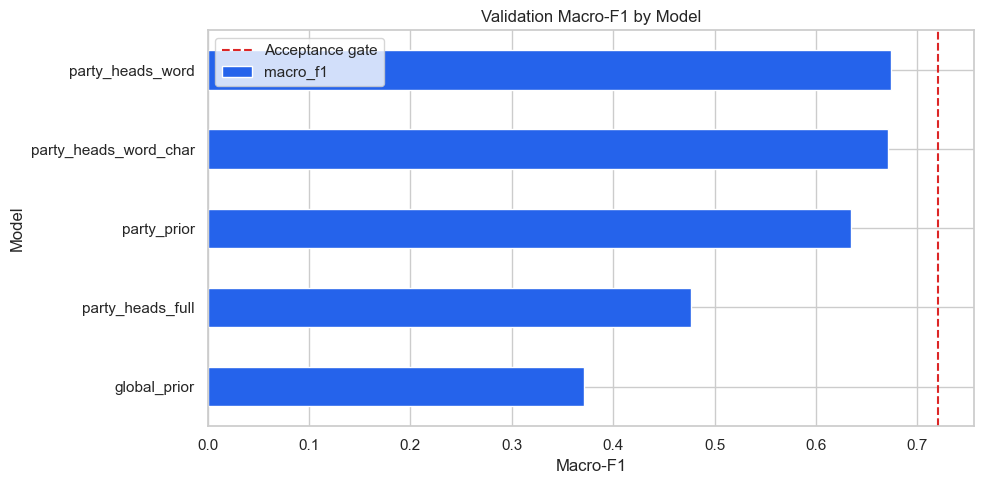

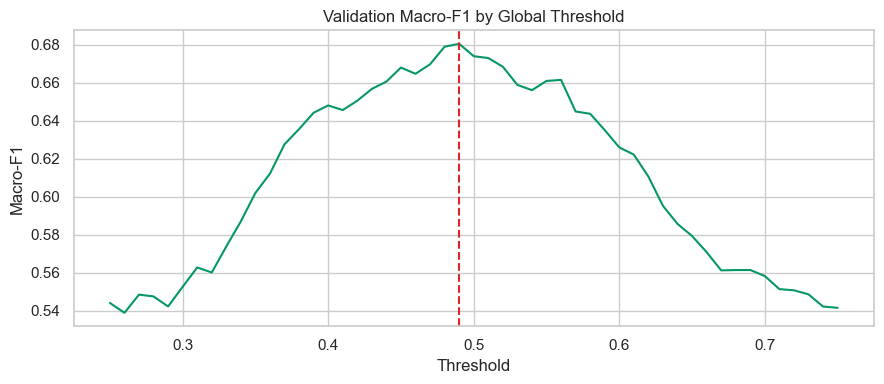

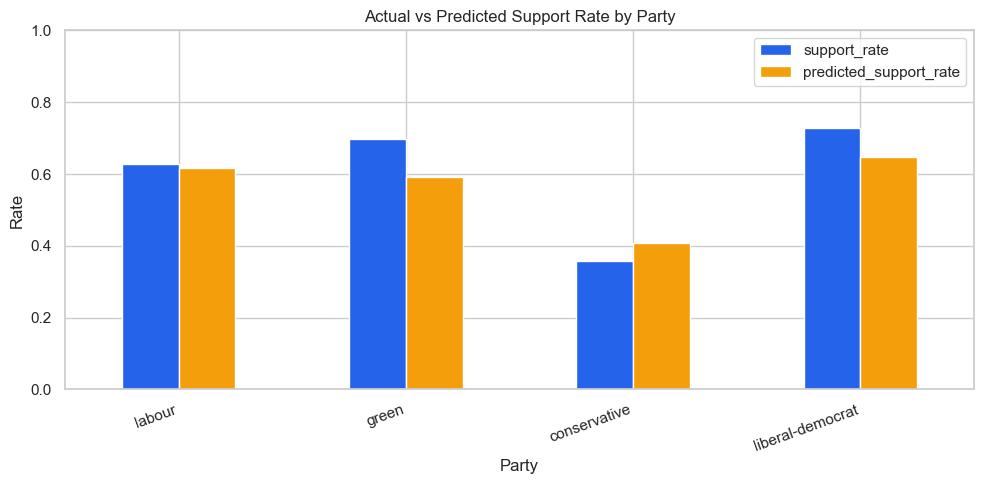

In [8]:
# 绘制所有基线和 party-aware 模型的 Validation Macro-F1。
plot_data = validation_comparison.sort_values('macro_f1')
ax = plot_data['macro_f1'].plot(
    kind='barh', figsize=(10, 5), color='#2563EB'
)
ax.axvline(
    MIN_VALIDATION_MACRO_F1,
    color='#DC2626',
    linestyle='--',
    label='Acceptance gate',
)
ax.set_title('Validation Macro-F1 by Model')
ax.set_xlabel('Macro-F1')
ax.set_ylabel('Model')
ax.legend()
plt.tight_layout()
plt.show()

# 显示全局阈值变化对 Macro-F1 的影响。
ax = threshold_curve.plot(
    x='threshold', y='macro_f1', figsize=(9, 4), color='#059669', legend=False
)
ax.axvline(selected_threshold, color='#DC2626', linestyle='--')
ax.set_title('Validation Macro-F1 by Global Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Macro-F1')
plt.tight_layout()
plt.show()

# 绘制各政党的真实支持率和预测支持率。
rate_plot = validation_party_metrics.set_index('party')[
    ['support_rate', 'predicted_support_rate']
]
ax = rate_plot.plot(kind='bar', figsize=(10, 5), color=['#2563EB', '#F59E0B'])
ax.set_title('Actual vs Predicted Support Rate by Party')
ax.set_xlabel('Party')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

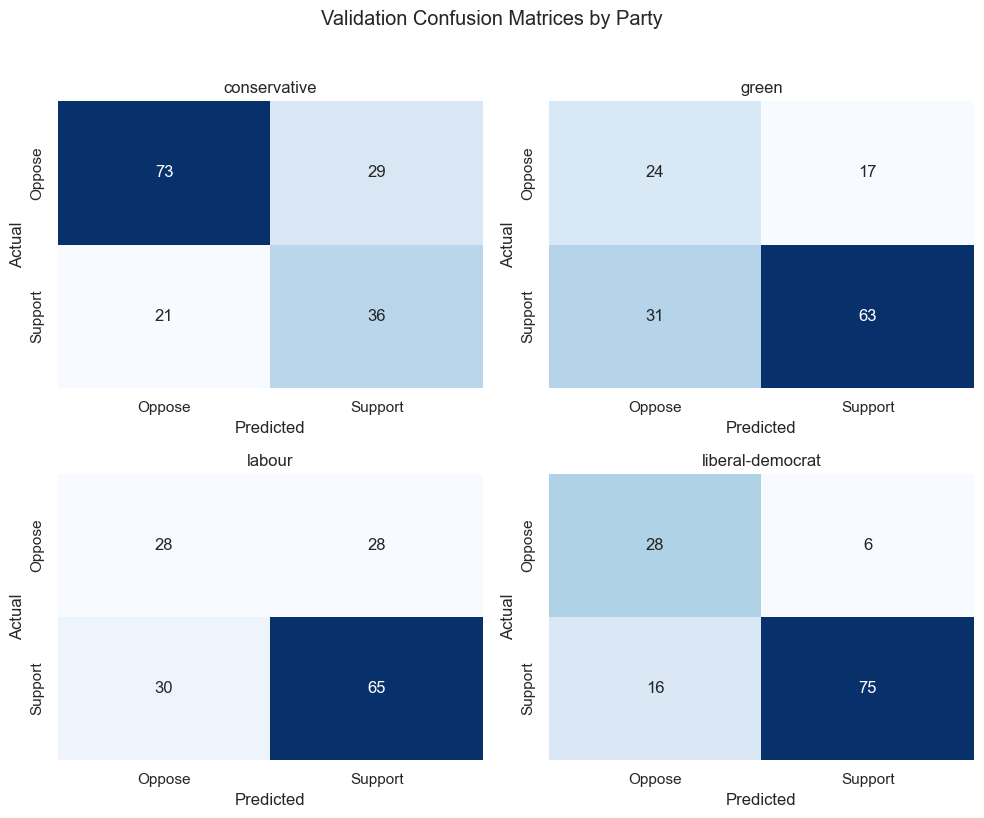

In [9]:
# 为每个政党显示混淆矩阵，定位 support/oppose 中哪一类更容易出错。
selected_predictions = (
    selected_validation_probabilities >= selected_threshold
).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, party in zip(axes.ravel(), sorted(validation['party'].unique())):
    mask = validation['party'].eq(party).to_numpy()
    matrix = confusion_matrix(
        y_validation[mask], selected_predictions[mask], labels=[0, 1]
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Oppose', 'Support'],
        yticklabels=['Oppose', 'Support'],
        ax=ax,
    )
    ax.set_title(party)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Validation Confusion Matrices by Party', y=1.02)
plt.tight_layout()
plt.show()

## 8. Inspect party-specific word signals

下面仅检查 word TF-IDF 分类头的系数，帮助理解同一个词在不同政党模型中是否呈现不同方向。正系数更倾向 `support`，负系数更倾向 `oppose`。这些是相关性，不应解释为因果关系。

In [10]:
# 提取每个政党 word 模型中最强的支持词和反对词。
word_features = fitted_transformers['word'].get_feature_names_out()
word_signal_rows = []

for party, classifier in fitted_party_heads['party_heads_word'].items():
    coefficients = classifier.coef_.ravel()
    strongest_oppose = np.argsort(coefficients)[:15]
    strongest_support = np.argsort(coefficients)[-15:][::-1]

    for rank, index in enumerate(strongest_support, start=1):
        word_signal_rows.append({
            'party': party,
            'direction': 'support',
            'rank': rank,
            'feature': word_features[index],
            'coefficient': coefficients[index],
        })
    for rank, index in enumerate(strongest_oppose, start=1):
        word_signal_rows.append({
            'party': party,
            'direction': 'oppose',
            'rank': rank,
            'feature': word_features[index],
            'coefficient': coefficients[index],
        })

word_signals = pd.DataFrame(word_signal_rows)
word_signals.to_csv(
    OUTPUT_DIR / 'party_specific_word_signals.csv', index=False
)

for party in sorted(word_signals['party'].unique()):
    print(f'\n=== {party} ===')
    display(
        word_signals[word_signals['party'].eq(party)]
        .pivot(index='rank', columns='direction', values='feature')
    )


=== conservative ===


direction,oppose,support
rank,,
1,lords amendment,draft
2,lords,regulations
3,disagree,reading
4,disagrees with,house on
5,disagrees,before this
6,house disagrees,be approved
7,with lords,laid
8,title disagree,laid before
9,disagree lords,approved



=== green ===


direction,oppose,support
rank,,
1,reading,lords amendment
2,draft,lords
3,third,disagree
4,third reading,with
5,the bill,with lords
6,the draft,disagrees with
7,eu exit,disagrees
8,leave,house disagrees
9,regulations,disagree lords



=== labour ===


direction,oppose,support
rank,,
1,draft,lords
2,reading,lords amendment
3,third,disagree
4,regulations,with lords
5,eu exit,disagrees
6,leave,disagrees with
7,out clause,with
8,exit,house disagrees
9,reading title,disagree lords



=== liberal-democrat ===


direction,oppose,support
rank,,
1,reading,lords
2,third,lords amendment
3,draft,disagree
4,the bill,with lords
5,third reading,disagrees with
6,eu exit,disagrees
7,exit,house disagrees
8,reading title,with
9,second reading,title disagree


## 9. Save Validation predictions

这些输出用于后续错误分析，不包含任何 Test 预测。

In [11]:
# 保存必要的 Validation 审计字段，便于检查错误议案。
validation_predictions = validation[[
    'row_id', 'division_key', 'motion_date', 'party',
    'motion_title_clean', 'motion_type', 'motion_family',
    'policy_domain_primary', 'party_role',
    'final_object_government_backed', TARGET,
]].copy()
validation_predictions['predicted_support_probability'] = (
    selected_validation_probabilities
)
validation_predictions['predicted_label'] = selected_predictions
validation_predictions['is_correct'] = (
    validation_predictions['predicted_label'].eq(
        validation_predictions[TARGET]
    )
)
validation_predictions.to_csv(
    OUTPUT_DIR / 'party_aware_validation_predictions.csv', index=False
)

display(
    validation_predictions.sort_values(
        ['is_correct', 'party', 'motion_date']
    ).head(20)
)

,row_id,division_key,motion_date,party,motion_title_clean,motion_type,motion_family,policy_domain_primary,party_role,final_object_government_backed,target_binary_support,predicted_support_probability,predicted_label,is_correct
27,pw-2024-01-15-42-commons__conservative,pw-2024-01-15-42-commons,2024-01-15,conservative,Clause 1 - Prohibition of export of livestock ...,amendment,amendment_or_clause,economy_finance_business,governing_party,NaN,0,0.572584,1,False
39,pw-2024-01-16-45-commons__conservative,pw-2024-01-16-45-commons,2024-01-16,conservative,Leave for Bill: Scotland (Self-Determination),bill_introduction,bill_stage,constitution_democracy_devolution,governing_party,0.0,0,0.554265,1,False
68,pw-2024-01-17-57-commons__conservative,pw-2024-01-17-57-commons,2024-01-17,conservative,Clause 9 - Commencement and transitional provi...,amendment,amendment_or_clause,immigration_asylum,governing_party,1.0,0,0.549369,1,False
116,pw-2024-02-20-75-commons__conservative,pw-2024-02-20-75-commons,2024-02-20,conservative,Clause 1 - Duty to invite applications for off...,amendment,amendment_or_clause,economy_finance_business,governing_party,0.0,0,0.559534,1,False
117,pw-2024-02-20-76-commons__conservative,pw-2024-02-20-76-commons,2024-02-20,conservative,Clause 1 - Duty to invite applications for off...,amendment,amendment_or_clause,economy_finance_business,governing_party,0.0,0,0.597294,1,False
147,pw-2024-03-12-89-commons__conservative,pw-2024-03-12-89-commons,2024-03-12,conservative,6. Capital gains tax (reduction in higher rate...,amendment,amendment_or_clause,economy_finance_business,governing_party,NaN,1,0.419271,0,False
164,pw-2024-03-14-97-commons__conservative,pw-2024-03-14-97-commons,2024-03-14,conservative,Supplementary Estimates 2023-24,financial,finance,constitution_democracy_devolution,governing_party,1.0,1,0.465225,0,False
288,pw-2024-04-24-137-commons__conservative,pw-2024-04-24-137-commons,2024-04-24,conservative,Renters (Reform) Bill: New Clause 15 - Notices...,add_clause_to_bill,amendment_or_clause,housing_planning_local_government,governing_party,NaN,1,0.291947,0,False
291,pw-2024-04-24-138-commons__conservative,pw-2024-04-24-138-commons,2024-04-24,conservative,New Clause 30: Renters (Reform) Bill,proposed_clause,amendment_or_clause,justice_crime_policing,governing_party,1.0,1,0.364282,0,False
294,pw-2024-04-24-139-commons__conservative,pw-2024-04-24-139-commons,2024-04-24,conservative,Clause 116 - Commencement and application,amendment,amendment_or_clause,housing_planning_local_government,governing_party,NaN,1,0.466041,0,False


## 10. Optional final Test

保持 `RUN_FINAL_TEST=False`，直到 Validation 结果已经讨论并冻结模型设计。启用后会用 Train+Validation 重新建立共享特征并训练四个政党分类头，然后只评测一次 Test。

In [12]:
test_metrics = None
test_party_metrics = None

if RUN_FINAL_TEST:
    # 模型设计确定后，把 Train 和 Validation 合并用于最终训练。
    development = pd.concat([train, validation], ignore_index=True)
    development_matrices, test_matrices, final_transformers = (
        fit_shared_features(development, test)
    )

    test_probabilities, final_party_heads, final_training_audit = (
        fit_party_heads(
            development,
            test,
            development_matrices[selected_model_name],
            test_matrices[selected_model_name],
        )
    )
    test_metrics = evaluate_probabilities(
        test[TARGET].to_numpy(),
        test_probabilities,
        threshold=selected_threshold,
    )
    test_party_metrics = subgroup_metrics(
        test,
        test_probabilities,
        'party',
        selected_threshold,
    )

    test_predictions = test[[
        'row_id', 'division_key', 'motion_date', 'party',
        'motion_title_clean', TARGET,
    ]].copy()
    test_predictions['predicted_support_probability'] = test_probabilities
    test_predictions['predicted_label'] = (
        test_probabilities >= selected_threshold
    ).astype(int)
    test_predictions.to_csv(
        OUTPUT_DIR / 'party_aware_test_predictions.csv', index=False
    )
    test_party_metrics.to_csv(
        OUTPUT_DIR / 'party_aware_test_party_metrics.csv', index=False
    )

    display(pd.Series(test_metrics, name='test').to_frame())
    display(test_party_metrics.round(3))
else:
    print('Test was not run. Keep RUN_FINAL_TEST=False during model development.')

Test was not run. Keep RUN_FINAL_TEST=False during model development.


## 11. Summary for review

运行结束后，只需要把下面这个 Cell 的文本输出发回给我。

In [13]:
summary_lines = [
    '=== PARTY-AWARE SUMMARY FOR REVIEW ===',
    f'Selected model: {selected_model_name}',
    f'Validation threshold: {selected_threshold:.2f}',
    f'Validation Macro-F1: {selected_validation_metrics["macro_f1"]:.3f}',
    f'Validation Accuracy: {selected_validation_metrics["accuracy"]:.3f}',
    f'Validation ROC-AUC: {selected_validation_metrics["roc_auc"]:.3f}',
    f'Party-prior Macro-F1: {party_prior_macro_f1:.3f}',
    f'Improvement over party prior: {improvement_over_party_prior:.3f}',
    f'Worst-party Macro-F1: {worst_party_macro_f1:.3f}',
    f'Acceptance gates: {acceptance_checks}',
    f'Next step: {next_step}',
    'Party metrics:',
    validation_party_metrics.round(3).to_string(index=False),
    f'RUN_FINAL_TEST: {RUN_FINAL_TEST}',
    (
        'Test result: NOT RUN'
        if test_metrics is None
        else f'Test Macro-F1: {test_metrics["macro_f1"]:.3f}'
    ),
    '=== END PARTY-AWARE SUMMARY ===',
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

with open(OUTPUT_DIR / 'party_aware_summary.txt', 'w', encoding='utf-8') as file:
    file.write(summary_text)

=== PARTY-AWARE SUMMARY FOR REVIEW ===
Selected model: party_heads_word
Validation threshold: 0.49
Validation Macro-F1: 0.680
Validation Accuracy: 0.688
Validation ROC-AUC: 0.720
Party-prior Macro-F1: 0.635
Improvement over party prior: 0.046
Worst-party Macro-F1: 0.591
Acceptance gates: {'macro_f1_gate': False, 'party_prior_improvement_gate': False, 'worst_party_gate': False}
Next step: Party-aware baseline does not pass; inspect errors before deciding whether P2 is the limiting factor.
Party metrics:
           party  rows  support_rate  predicted_support_rate  mean_probability  accuracy  balanced_accuracy  macro_f1
          labour   151         0.629                   0.616             0.557     0.616              0.592     0.591
           green   135         0.696                   0.593             0.552     0.644              0.628     0.612
    conservative   159         0.358                   0.409             0.464     0.686              0.674     0.668
liberal-democrat   1